### <div style="background-color:blue; color:white; padding:10px;"> Import libraries </div>

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import scipy.sparse as sp
from sklearn.metrics import average_precision_score
from sklearn.metrics import f1_score, precision_score, recall_score

### <div style="background-color:blue; color:white; padding:10px;"> Paths and parameters </div>

In [2]:
FEATURES_CSV = "../Features/EPIC/P01_04_vgg_fused_features.csv"
LABELS_CSV = "../Labels/EPIC/P01_04_vgg_fused_labeled.csv"
GRAPH_PATH = "../Graph/EPIC/P01_04_vgg_fused_transition_matrix.npz"

MODEL_PATH = "../Model/EPIC/P01_04_vgg_fused_model.pt"
PREDICTIONS_CSV = "../Prediction/EPIC/P01_04_vgg_fused_predictions.csv"
METRICS_CSV = "../Metrics/EPIC/P01_04_vgg_fused_metrics.csv"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LR = 3e-4
# ALPHA = 0.5  # label propagation coefficient

print("Device:", DEVICE)

Device: cuda


### <div style="background-color:blue; color:white; padding:10px;"> Load features and labels </div>

In [3]:
features_df = pd.read_csv(FEATURES_CSV)
labels_df = pd.read_csv(LABELS_CSV)
features = features_df.drop(columns=["frame_id"]).values.astype(np.float32)
labels = labels_df.drop(columns=["frame_id"]).values.astype(np.float32)
T, FEATURE_DIM = features.shape
_, NUM_CLASSES = labels.shape
print("Features:", features.shape)
print("Labels:", labels.shape)

Features: (6180, 512)
Labels: (6180, 29)


### <div style="background-color:blue; color:white; padding:10px;">Load transition matrix</div>

In [4]:
P_sparse = sp.load_npz(GRAPH_PATH)
P = P_sparse.toarray().astype(np.float32)
P_tensor = torch.from_numpy(P).to(DEVICE)
print("Transition matrix:", P_tensor.shape)

Transition matrix: torch.Size([6180, 6180])


### <div style="background-color:blue; color:white; padding:10px;">Convert data to torch tensors</div>

In [5]:
X = torch.from_numpy(features).float().to(DEVICE)
X = F.normalize(X, dim=1)
Y = torch.from_numpy(labels).float().to(DEVICE)

In [6]:
pos_counts = labels.sum(axis=0)
neg_counts = len(labels) - pos_counts
weights = neg_counts / (pos_counts + 1e-12)
weights = torch.from_numpy(weights).float().to(DEVICE)

In [7]:
print("X:", X.shape)
print("labels:", labels.shape)
print("P:", P_tensor.shape)

X: torch.Size([6180, 512])
labels: (6180, 29)
P: torch.Size([6180, 6180])


### <div style="background-color:blue; color:white; padding:10px;"> Define classifier </div>

In [8]:
class Classifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3), 
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.net(x)

In [9]:
model = Classifier(FEATURE_DIM, NUM_CLASSES).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.BCEWithLogitsLoss(pos_weight=weights)

### <div style="background-color:blue; color:white; padding:10px;">Random Walk label propagation function</div>

In [10]:
def residual_random_walk(logits, P, alpha=0.5, steps=5):
    Y = torch.sigmoid(logits)
    confidence = torch.abs(Y - 0.5) * 2
    uncertainty = 1 - confidence
    for _ in range(steps):
        Y = Y + alpha * uncertainty * (torch.matmul(P, Y) - Y)
    return Y

### <div style="background-color:blue; color:white; padding:10px;"> Training loop </div>

In [21]:
EPOCHS = 200

for epoch in range(EPOCHS):
    model.train()
    # Forward pass (FULL GRAPH)
    logits = model(X)                  # (T × C)
    pred = torch.sigmoid(logits)       # (T × C)
    loss_cls = criterion(logits, Y)
    loss_graph = ((pred - torch.matmul(P_tensor, pred))**2).mean()
    loss_temporal = ((pred[1:] - pred[:-1])**2).mean()
    loss = loss_cls + 0.5 * loss_graph + 0.2 * loss_temporal
    # Backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    print(f"Epoch {epoch+1}, Total Loss: {loss.item():.4f}")

Epoch 1, Total Loss: 0.6669
Epoch 2, Total Loss: 0.6692
Epoch 3, Total Loss: 0.6676
Epoch 4, Total Loss: 0.6679
Epoch 5, Total Loss: 0.6668
Epoch 6, Total Loss: 0.6677
Epoch 7, Total Loss: 0.6683
Epoch 8, Total Loss: 0.6673
Epoch 9, Total Loss: 0.6672
Epoch 10, Total Loss: 0.6672
Epoch 11, Total Loss: 0.6668
Epoch 12, Total Loss: 0.6674
Epoch 13, Total Loss: 0.6666
Epoch 14, Total Loss: 0.6682
Epoch 15, Total Loss: 0.6676
Epoch 16, Total Loss: 0.6684
Epoch 17, Total Loss: 0.6680
Epoch 18, Total Loss: 0.6687
Epoch 19, Total Loss: 0.6672
Epoch 20, Total Loss: 0.6673
Epoch 21, Total Loss: 0.6677
Epoch 22, Total Loss: 0.6684
Epoch 23, Total Loss: 0.6679
Epoch 24, Total Loss: 0.6677
Epoch 25, Total Loss: 0.6692
Epoch 26, Total Loss: 0.6673
Epoch 27, Total Loss: 0.6690
Epoch 28, Total Loss: 0.6672
Epoch 29, Total Loss: 0.6681
Epoch 30, Total Loss: 0.6676
Epoch 31, Total Loss: 0.6697
Epoch 32, Total Loss: 0.6681
Epoch 33, Total Loss: 0.6678
Epoch 34, Total Loss: 0.6679
Epoch 35, Total Loss: 0

### <div style="background-color:blue; color:white; padding:10px;"> Final prediction </div>

In [22]:
model.eval()
with torch.no_grad():
    logits = model(X)
    # BEFORE propagation
    before_propagation = torch.sigmoid(logits).cpu().numpy()
    # AFTER propagation
    propagated = residual_random_walk(logits, P_tensor, alpha=0.5)
    propagated = torch.clamp(propagated, 0, 1)
    
    predictions = propagated.cpu().numpy()
    
    after_propagation = propagated.cpu().numpy()
    
    # =========================
    # DEFINE SCORES FOR ROC
    # =========================
    scores_before = before_propagation
    scores_after = after_propagation

In [23]:
before_df = pd.DataFrame(before_propagation)
before_df.insert(0, "frame_id", np.arange(len(before_df)))
before_df.to_csv("../Prediction/EPIC/P01_04_vgg_fused_before_propagation.csv", index=False)

after_df = pd.DataFrame(after_propagation)
after_df.insert(0, "frame_id", np.arange(len(after_df)))
after_df.to_csv("../Prediction/EPIC/P01_04_vgg_fused_after_propagation.csv", index=False)

print("Saved before_propagation.csv and after_propagation.csv")

Saved before_propagation.csv and after_propagation.csv


### <div style="background-color:#ff0000; color:white; padding:10px;"> Compute evaluation metrics </div>

### <div style="background-color:blue; color:white; padding:10px;"> mAP (mean Average Precision), LRAP, Top-1 & Top-5, </div>

In [24]:
# mAP
y_true = labels 
y_pred = predictions
AP = []
for c in range(NUM_CLASSES):
    ap = average_precision_score(y_true[:, c], y_pred[:, c])
    AP.append(ap)
mAP = np.mean(AP)
print("mAP:", mAP)

# LRAP
from sklearn.metrics import label_ranking_average_precision_score
lrap = label_ranking_average_precision_score(y_true, y_pred)
print("LRAP:", lrap)

# Top-1 and Top-5 accuracy
true_labels = [np.where(row == 1)[0] for row in y_true]

top1_correct = 0
top5_correct = 0

for i in range(len(y_pred)):
    top1 = np.argsort(y_pred[i])[-1:]
    top5 = np.argsort(y_pred[i])[-5:]
    gt = true_labels[i]
    if any(t in gt for t in top1):
        top1_correct += 1
    if any(t in gt for t in top5):
        top5_correct += 1
top1_acc = top1_correct / len(y_pred)
top5_acc = top5_correct / len(y_pred)

print("Top-1 Accuracy:", top1_acc)
print("Top-5 Accuracy:", top5_acc)

threshold = np.percentile(y_pred, 90)
y_pred_binary = (y_pred > threshold).astype(int)

mAP: 0.9404577096550577
LRAP: 0.9557335490830623
Top-1 Accuracy: 0.7506472491909385
Top-5 Accuracy: 0.8284789644012945


### Hamming Loss

In [25]:
hamming = np.mean(y_true != y_pred_binary)
print("Hamming Loss:", hamming)

Hamming Loss: 0.07000334784064279


### Save predictions

In [26]:
pred_df = pd.DataFrame(y_pred)
pred_df.insert(0, "frame_id", np.arange(T))
pred_df.to_csv(PREDICTIONS_CSV, index=False)
print("Saved predictions:", PREDICTIONS_CSV)

Saved predictions: ../Prediction/EPIC/P01_04_vgg_fused_predictions.csv


### Save metrics

In [27]:
metrics = {
    "mAP": mAP,
#     "F1-micro": f1_micro,
#     "F1-macro": f1_macro,
#     "Precision": precision,
#     "Recall": recall,
    "Hamming Loss": hamming}
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(METRICS_CSV, index=False)
print("Saved metrics:", METRICS_CSV)

Saved metrics: ../Metrics/EPIC/P01_04_vgg_fused_metrics.csv


In [28]:
met=pd.read_csv("../Metrics/EPIC/P01_04_vgg_fused_metrics.csv")
met

,mAP,Hamming Loss
0,0.940458,0.070003


### <div style="background-color:blue; color:white; padding:10px;"> Save Model </div>

In [29]:
torch.save(model.state_dict(), MODEL_PATH)
print("Saved model:", MODEL_PATH)

Saved model: ../Model/EPIC/P01_04_vgg_fused_model.pt


In [30]:
baseline_map = np.mean([
    average_precision_score(y_true[:, c], before_propagation[:, c])
    for c in range(NUM_CLASSES)
])

print("Baseline mAP:", baseline_map)
print("Propagated mAP:", mAP)
print("Improvement:", mAP - baseline_map)

Baseline mAP: 0.9374241021705905
Propagated mAP: 0.9404577096550577
Improvement: 0.003033607484467238


### <div style="background-color:blue; color:white; padding:10px;"> ROC Curve </div>


Top 5 hardest classes:
Class 0: AUC=0.959
Class 14: AUC=0.992
Class 5: AUC=0.994
Class 24: AUC=0.995
Class 7: AUC=0.996


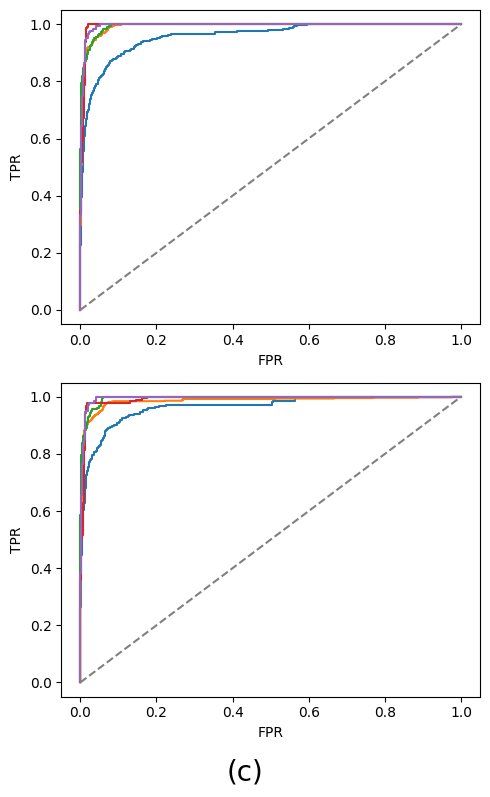

In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# =========================
# COMPUTE AUC
# =========================
auc_scores = []
for c in range(NUM_CLASSES):
    fpr_b, tpr_b, _ = roc_curve(y_true[:, c], scores_before[:, c])
    auc_b = auc(fpr_b, tpr_b)
    auc_scores.append((c, auc_b))

# Sort → hardest classes
auc_scores_sorted = sorted(auc_scores, key=lambda x: x[1])
hardest_classes = auc_scores_sorted[:5]

print("\nTop 5 hardest classes:")
for cls, auc_b in hardest_classes:
    print(f"Class {cls}: AUC={auc_b:.3f}")

# =========================
# VERTICAL PLOT (UP & DOWN)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(5, 8))  # 2 rows, 1 column

# -------- BEFORE RW (Top) --------
for cls, _ in hardest_classes:
    fpr_b, tpr_b, _ = roc_curve(y_true[:, cls], scores_before[:, cls])
    auc_b = auc(fpr_b, tpr_b)
    axes[0].plot(fpr_b, tpr_b, label=f'Class {cls} ({auc_b:.2f})')

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
# axes[0].set_title("Before RW")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
# axes[0].legend(fontsize=7)
axes[0].grid(False)

# -------- AFTER RW (Bottom) --------
for cls, _ in hardest_classes:
    fpr_a, tpr_a, _ = roc_curve(y_true[:, cls], scores_after[:, cls])
    auc_a = auc(fpr_a, tpr_a)
    axes[1].plot(fpr_a, tpr_a, label=f'Class {cls} ({auc_a:.2f})')

axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
# axes[1].set_title("After RW")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
# axes[1].legend(fontsize=7)
axes[1].grid(False)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # Leave space at bottom for caption

# =========================
# SINGLE CAPTION BELOW BOTH
# =========================
fig.text(
    0.5, 0.01,
    "(c)",
    ha='center', va='bottom', fontsize=20
)

# =========================
# SAVE
# =========================
plt.savefig("ROC_Images/P01_04_roc.eps",
            format='eps', dpi=1000, bbox_inches='tight')
plt.show()

In [32]:
import pandas as pd

ANNOTATION_PATH = r"D:\Datasets\Datasets\EPIC_Kitchen\Label\P01_04.csv"  # update path

df = pd.read_csv(ANNOTATION_PATH)

# Keep only required columns
df = df[["ActionLabel", "Verb", "Noun"]]

# Create readable action name
df["ActionName"] = df["Verb"] + " " + df["Noun"]

# Remove duplicates
df = df.drop_duplicates()

# Create mapping
action_map = dict(zip(df["ActionLabel"], df["ActionName"]))

print("Mapping loaded:", len(action_map))

Mapping loaded: 29


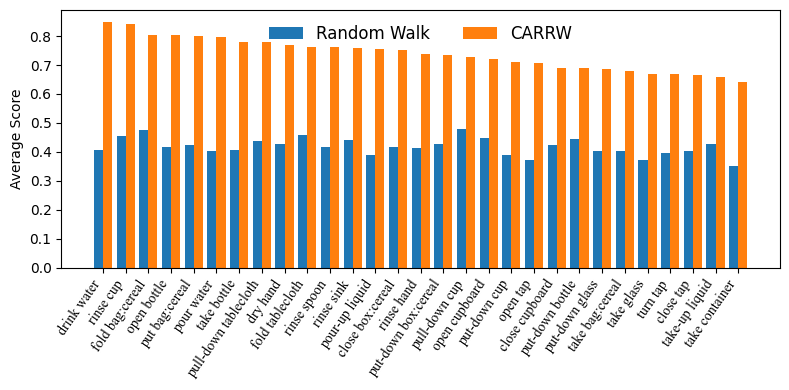

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# AGGREGATION (MEAN)
# =========================
def topk_mean(scores, k_ratio=0.1):
    k = int(len(scores) * k_ratio)
    topk_vals = np.sort(scores)[-k:]
    return np.mean(topk_vals)

before_mean = scores_before.mean(axis=0)   # (C,)
after_agg  = np.array([topk_mean(scores_after[:, c])  for c in range(NUM_CLASSES)])

# =========================
# SELECT TOP-K CLASSES
# =========================
TOP_K = 29
top_indices = np.argsort(after_agg)[-TOP_K:][::-1]
# =========================
# GET ACTION NAMES
# =========================
class_names = [action_map.get(i, f"Class_{i}") for i in top_indices]

before_vals = before_mean[top_indices]
after_vals  = after_agg[top_indices]

x = np.arange(len(class_names))
width = 0.40
plt.figure(figsize=(8,4))
# BEFORE (baseline)
plt.bar(x - width/2, before_vals,
        width, label='Random Walk')
# AFTER (proposed)
plt.bar(x + width/2, after_vals,
        width, label='CARRW')
# Labels
plt.xticks(x, class_names, rotation=55, ha='right', fontfamily='Times New Roman', fontsize=10)
plt.ylabel("Average Score")
# plt.title("Per-Class Score Comparison (Before vs After RW)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0), 
           ncol=2, frameon=False, fontsize=12)
plt.grid(axis='y', linestyle='', alpha=0.3)
# # Save
# plt.savefig("ROC_Images/P01_04_per_class_comparison.eps",
#             format='eps', dpi=1000, bbox_inches='tight')
plt.tight_layout()
plt.show()

## Overlapping Transparent Bar

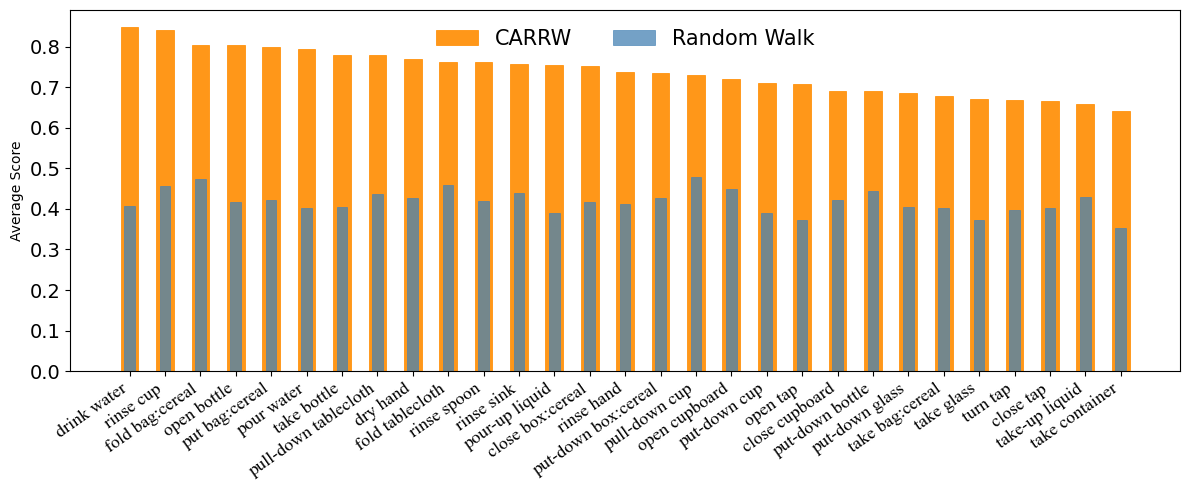

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# AGGREGATION (MEAN)
# =========================
def topk_mean(scores, k_ratio=0.1):
    k = int(len(scores) * k_ratio)
    topk_vals = np.sort(scores)[-k:]
    return np.mean(topk_vals)

before_mean = scores_before.mean(axis=0)
after_agg   = np.array([topk_mean(scores_after[:, c]) for c in range(NUM_CLASSES)])

# =========================
# SELECT TOP-K CLASSES
# =========================
TOP_K = 29
top_indices = np.argsort(after_agg)[-TOP_K:][::-1]

# =========================
# GET ACTION NAMES
# =========================
class_names = [action_map.get(i, f"Class_{i}") for i in top_indices]
before_vals = before_mean[top_indices]
after_vals  = after_agg[top_indices]

x     = np.arange(len(class_names))
width = 0.50

plt.figure(figsize=(12, 5))

# AFTER (proposed) — plotted first so BEFORE overlaps on top
plt.bar(x, after_vals,
        width, label='CARRW',
        color='darkorange', alpha=0.90, edgecolor='darkorange', linewidth=0.6)

# BEFORE (baseline) — plotted second, slightly narrower, more transparent
plt.bar(x, before_vals,
        width * 0.6, label='Random Walk',
        color='steelblue', alpha=0.75, edgecolor='steelblue', linewidth=0.6)

# Labels
plt.xticks(x, class_names, rotation=35, ha='right',
           fontfamily='Times New Roman', fontsize=13)
plt.yticks(fontsize=14)
plt.ylabel("Average Score")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0),
           ncol=2, frameon=False, fontsize=15)
plt.grid(False)
# # Save
# plt.savefig("ROC_Images/P01_04_per_class_comparison.eps",
#             format='eps', dpi=1000, bbox_inches='tight')
plt.tight_layout()
plt.show()

## Lollipop Chart

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


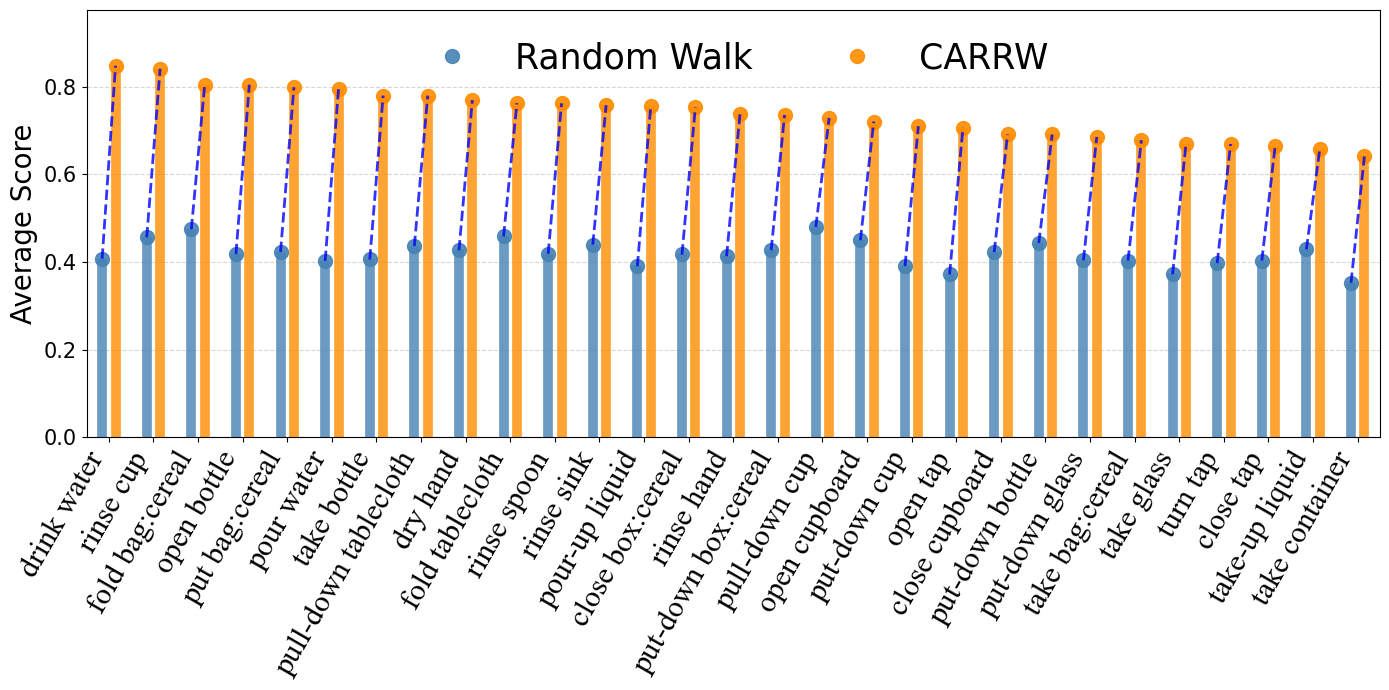

In [141]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# AGGREGATION (MEAN)
# =========================
def topk_mean(scores, k_ratio=0.1):
    k = int(len(scores) * k_ratio)
    topk_vals = np.sort(scores)[-k:]
    return np.mean(topk_vals)

before_mean = scores_before.mean(axis=0)
after_agg   = np.array([topk_mean(scores_after[:, c]) for c in range(NUM_CLASSES)])

# =========================
# SELECT TOP-K CLASSES
# =========================
TOP_K = 29
top_indices = np.argsort(after_agg)[-TOP_K:][::-1]

# =========================
# GET ACTION NAMES
# =========================
class_names = [action_map.get(i, f"Class_{i}") for i in top_indices]
before_vals = before_mean[top_indices]
after_vals  = after_agg[top_indices]

x = np.arange(len(class_names))

plt.figure(figsize=(14, 7))

# ---- BEFORE (baseline) lollipop ----
plt.vlines(x - 0.15, 0, before_vals,
           color='steelblue', linewidth=7.0, alpha=0.8)
plt.plot(x - 0.15, before_vals,
         'o', color='steelblue', markersize=10,
         label='Random Walk', alpha=0.9)

# ---- AFTER (proposed) lollipop ----
plt.vlines(x + 0.15, 0, after_vals,
           color='darkorange', linewidth=7.0, alpha=0.8)
plt.plot(x + 0.15, after_vals,
         'o', color='darkorange', markersize=10,
         label='CARRW', alpha=0.9)

# ---- Faint connector line between before and after dots ----
for i in range(len(x)):
    plt.plot([x[i] - 0.15, x[i] + 0.15],
             [before_vals[i], after_vals[i]],
             color='blue', linewidth=2.0, linestyle='--', alpha=0.8)

# Labels
plt.xticks(x, class_names, rotation=60, ha='right',
           fontfamily='Times New Roman', fontsize=22)

plt.ylabel("Average Score", fontsize=20)
plt.xlim(-0.5, len(class_names) - 0.5)
plt.ylim(0, max(after_vals.max(), before_vals.max()) * 1.15)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0),
           ncol=2, frameon=False, fontsize=25)
plt.yticks(fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
# Save
plt.savefig("ROC_Images/P01_04_per_class_comparison.eps",
            format='eps', dpi=1000, bbox_inches='tight')
plt.tight_layout()
plt.show()

## Heatmap Bar (color-encoded)

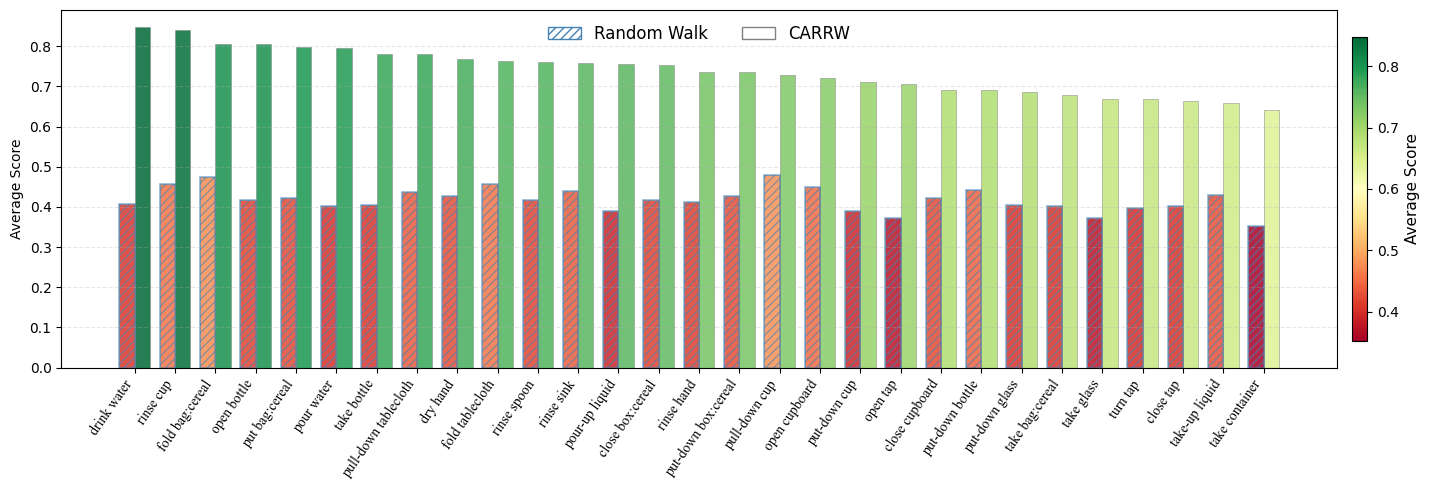

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# =========================
# AGGREGATION (MEAN)
# =========================
def topk_mean(scores, k_ratio=0.1):
    k = int(len(scores) * k_ratio)
    topk_vals = np.sort(scores)[-k:]
    return np.mean(topk_vals)

before_mean = scores_before.mean(axis=0)
after_agg   = np.array([topk_mean(scores_after[:, c]) for c in range(NUM_CLASSES)])

# =========================
# SELECT TOP-K CLASSES
# =========================
TOP_K = 29
top_indices = np.argsort(after_agg)[-TOP_K:][::-1]

# =========================
# GET ACTION NAMES
# =========================
class_names = [action_map.get(i, f"Class_{i}") for i in top_indices]
before_vals = before_mean[top_indices]
after_vals  = after_agg[top_indices]

# =========================
# COLOR NORMALIZATION
# =========================
all_vals  = np.concatenate([before_vals, after_vals])
norm      = mcolors.Normalize(vmin=all_vals.min(), vmax=all_vals.max())
cmap      = cm.RdYlGn   # Red=low, Yellow=mid, Green=high

x     = np.arange(len(class_names))
width = 0.38

fig, ax = plt.subplots(figsize=(16, 5))

# ---- BEFORE bars (color-encoded) ----
for i in range(len(x)):
    ax.bar(x[i] - width/2, before_vals[i],
           width, color=cmap(norm(before_vals[i])),
           edgecolor='gray', linewidth=0.4, alpha=0.85)

# ---- AFTER bars (color-encoded) ----
for i in range(len(x)):
    ax.bar(x[i] + width/2, after_vals[i],
           width, color=cmap(norm(after_vals[i])),
           edgecolor='gray', linewidth=0.4, alpha=0.85)

# ---- Hatch pattern to differentiate Before vs After ----
for i in range(len(x)):
    ax.bar(x[i] - width/2, before_vals[i],
           width, fill=False,
           edgecolor='steelblue', linewidth=1.2,
           hatch='////', alpha=0.6)

# ---- Colorbar ----
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.01, shrink=0.85)
cbar.set_label("Average Score", fontsize=11)

# ---- Custom legend ----
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='white', edgecolor='steelblue',
          hatch='////', label='Random Walk'),
    Patch(facecolor='white', edgecolor='gray',
          label='CARRW')
]
ax.legend(handles=legend_elements,
          loc='upper center', bbox_to_anchor=(0.5, 1.0),
          ncol=2, frameon=False, fontsize=12)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=55, ha='right',
                   fontfamily='Times New Roman', fontsize=10)
ax.set_ylabel("Average Score")
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()